# Interactive choropleth — ICSA / WICSA / ECSA affiliations by year

Reads `data/raw/icsa_affiliations.json`, counts author-institution rows by
country for each year, and shows a world choropleth with a **year slider**.
The colour scale is locked across years so maps are comparable.

In [1]:
import json
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

## 1. Config

In [2]:
INPUT_FILE = Path("../../data/raw/icsa_affiliations.json")
TITLE      = "ICSA / WICSA / ECSA author affiliations"

# colour scheme: near-white at 0 -> very dark red at the max (high contrast)
CMAP   = LinearSegmentedColormap.from_list(
    "white_darkred",
    ["#fff5f0", "#fcbba1", "#fc9272", "#fb6a4a", "#de2d26", "#a50f15", "#67000d"],
)
OCEAN  = "#cce5ff"   # sea / figure background
NODATA = "#eaeaea"   # countries with no rows that year

## 2. Load records & build `{year: {iso_a3: count}}`

In [3]:
with open(INPUT_FILE) as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["country_code"] = df["country_code"].str.upper().str.strip()
df = df.dropna(subset=["year", "country_code"])

# world geometry uses ISO alpha-3; the data has alpha-2 -> bridge them
try:
    import pycountry
    def a2_to_a3(a2):
        try:
            return pycountry.countries.get(alpha_2=a2).alpha_3
        except Exception:
            return None
except ImportError:
    A2_TO_A3 = {
        "AR":"ARG","AU":"AUS","AT":"AUT","BE":"BEL","BR":"BRA","CA":"CAN",
        "CH":"CHE","CL":"CHL","CN":"CHN","CO":"COL","CZ":"CZE","DE":"DEU",
        "DK":"DNK","EG":"EGY","ES":"ESP","FI":"FIN","FR":"FRA","GB":"GBR",
        "GR":"GRC","HK":"HKG","HU":"HUN","IE":"IRL","IL":"ISR","IN":"IND",
        "IR":"IRN","IT":"ITA","JP":"JPN","KR":"KOR","LU":"LUX","MX":"MEX",
        "MY":"MYS","NL":"NLD","NO":"NOR","NZ":"NZL","PL":"POL","PT":"PRT",
        "RO":"ROU","RU":"RUS","SE":"SWE","SG":"SGP","TR":"TUR","TW":"TWN",
        "UA":"UKR","US":"USA","ZA":"ZAF",
    }
    a2_to_a3 = lambda a2: A2_TO_A3.get(a2)
    print("pycountry not found - using built-in alpha-2->3 lookup (pip install pycountry for full coverage).")

df["iso_a3"] = df["country_code"].apply(a2_to_a3)
unmatched = sorted(df.loc[df["iso_a3"].isna(), "country_code"].unique())
if unmatched:
    print("Could not map to alpha-3:", unmatched)
df = df.dropna(subset=["iso_a3"])

counts_by_year = df.groupby(["year", "iso_a3"]).size().reset_index(name="count")
data = {
    int(y): dict(zip(g["iso_a3"], g["count"]))
    for y, g in counts_by_year.groupby("year")
}

YEARS = sorted(data)
VMAX  = int(counts_by_year["count"].max())   # lock colour scale across years
print(f"{len(df):,} rows | years {YEARS[0]}-{YEARS[-1]} | max country-year count = {VMAX}")

pycountry not found - using built-in alpha-2->3 lookup (pip install pycountry for full coverage).
Could not map to alpha-3: ['DZ', 'HR', 'IS', 'JO', 'SI', 'TH', 'TN']
1,800 rows | years 2010-2025 | max country-year count = 63


## 3. Load world geometry

`gpd.datasets` was removed in geopandas 1.x, so load Natural Earth from its source.

In [4]:
# Natural Earth, cached locally so it downloads only once (no slow re-fetch).
import urllib.request

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
CACHE  = Path("../../data/raw/ne_110m_admin_0_countries.zip")

if not CACHE.exists():
    print("downloading Natural Earth (one time)...")
    urllib.request.urlretrieve(url, CACHE)

world = gpd.read_file(CACHE)
world = world.rename(columns={"ADM0_A3": "iso_a3"})[["iso_a3", "geometry"]]
print(f"world geometry: {len(world)} countries (cached at {CACHE})")

world geometry: 177 countries (cached at ../../data/raw/ne_110m_admin_0_countries.zip)


## 4. Interactive map — drag the year slider

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


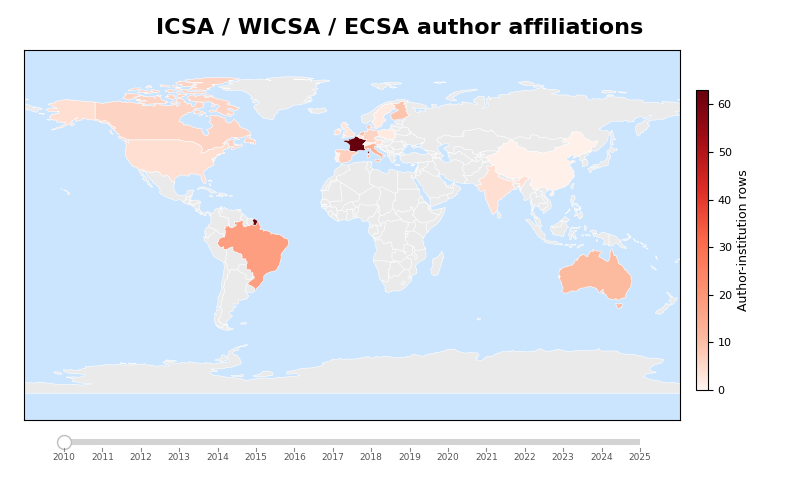

In [11]:
%matplotlib widget

norm = Normalize(vmin=0, vmax=VMAX)
BOUNDS = world.total_bounds          # [minx, miny, maxx, maxy] — lock the view to this

fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor("white")

# stop the figure reacting to the cursor: hide the ipympl toolbar / coordinate readout
for _attr in ("toolbar_visible", "header_visible", "footer_visible"):
    try:
        setattr(fig.canvas, _attr, False)
    except Exception:
        pass

MAP   = [0.03, 0.16, 0.82, 0.74]     # map fills most of the figure
SLD_Y = MAP[1] - 0.055               # slider tucked just under the map's bottom edge
map_ax    = fig.add_axes(MAP)
cax       = fig.add_axes([0.87, 0.22, 0.015, 0.60])
slider_ax = fig.add_axes([MAP[0] + 0.05, SLD_Y, MAP[2] - 0.10, 0.022])

fig.suptitle(TITLE, fontsize=16, fontweight="bold", y=0.965)
cb = fig.colorbar(ScalarMappable(cmap=CMAP, norm=norm), cax=cax)
cb.set_label("Author-institution rows", fontsize=9)
cb.ax.tick_params(labelsize=8)

def draw(year):
    year = int(year)
    map_ax.clear()
    map_ax.set_facecolor(OCEAN)
    map_ax.set_navigate(False)             # no pan/zoom following the cursor
    map_ax.format_coord = lambda x, y: ""  # no coordinate readout
    counts = data.get(year, {})
    w = world.copy()
    w["value"] = w["iso_a3"].map(counts)
    w[w["value"].isna()].plot(ax=map_ax, color=NODATA, edgecolor="white", linewidth=0.4)
    layer = w[w["value"].notna()]
    if not layer.empty:
        layer.plot(column="value", ax=map_ax, cmap=CMAP, norm=norm,
                   edgecolor="white", linewidth=0.4)
    # lock the frame so the map is the exact same size every year
    map_ax.set_xlim(BOUNDS[0], BOUNDS[2])
    map_ax.set_ylim(BOUNDS[1], BOUNDS[3])
    map_ax.set_aspect("equal", adjustable="datalim")
    map_ax.set_position(MAP)
    map_ax.set_xticks([]); map_ax.set_yticks([])
    fig.canvas.draw_idle()

year_slider = Slider(slider_ax, "", YEARS[0], YEARS[-1],
                     valinit=YEARS[0], valstep=1, color="#dc143c")
year_slider.valtext.set_visible(False)

# small per-year tick marks + labels right under the slider track (figure coords)
_x0, _w = slider_ax.get_position().x0, slider_ax.get_position().width
for _y in YEARS:
    _xf = _x0 + (_y - YEARS[0]) / (YEARS[-1] - YEARS[0]) * _w
    fig.add_artist(plt.Line2D([_xf, _xf], [SLD_Y - 0.006, SLD_Y],
                              transform=fig.transFigure, color="#888", lw=0.8))
    fig.text(_xf, SLD_Y - 0.010, str(_y), fontsize=6.5, ha="center", va="top", color="#555")

year_slider.on_changed(draw)
draw(YEARS[0])
plt.show()